In [5]:
# %% Imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import windows
import os
%matplotlib widget


In [15]:
# ---------- Inputs ----------
v_final = 0.150    # m/s
a_max   = 5.0      # m/s^2
# ----------------------------



print(f"t_accel = {v_final/a_max*1000} ms")

t_accel = 30.0 ms


In [43]:
data_dir = Path("~/eedm_jml/daqAnalysisAndExperiments/launch/measureTrackVelocityBeatNote/data_gitignore").expanduser()
files = sorted(data_dir.glob("*.npz"))

if len(files) == 1:
    fname = files[0]
    print(f"One file found, using: {fname.name}")
elif len(files) == 0:
    raise FileNotFoundError(f"No .npz files in {data_dir}")
else:
    most_recent = max(files, key=lambda p: p.stat().st_mtime)
    print(f"{len(files)} files found. Most recent: {most_recent.name}")
    user_in = input("Enter filename (blank = most recent): ").strip()
    fname = data_dir / user_in if user_in else most_recent
    print(f"Using: {fname.name}")

d = np.load(fname, allow_pickle=True)
print("Keys:", list(d.keys()))

t = d["times"]
v = d["voltages"]
fs = float(d["sample_rate"])
xinc = 1.0 / fs

print(f"N = {len(v)},  fs = {fs/1e6:.1f} MSa/s,  duration = {len(v)*xinc*1e3:.2f} ms")
print(f"V range: {v.min()*1e3:.2f} to {v.max()*1e3:.2f} mV")

31 files found. Most recent: beat_20260514_172819.npz
Using: beat_20260514_172819.npz
Keys: ['times', 'voltages', 'sample_rate', 'timestamp']
N = 10000000,  fs = 50.0 MSa/s,  duration = 200.00 ms
V range: -58021.85 to -57988.73 mV


Cut: 0.500 to 190.000 ms (9474999 pts, 189.50 ms)


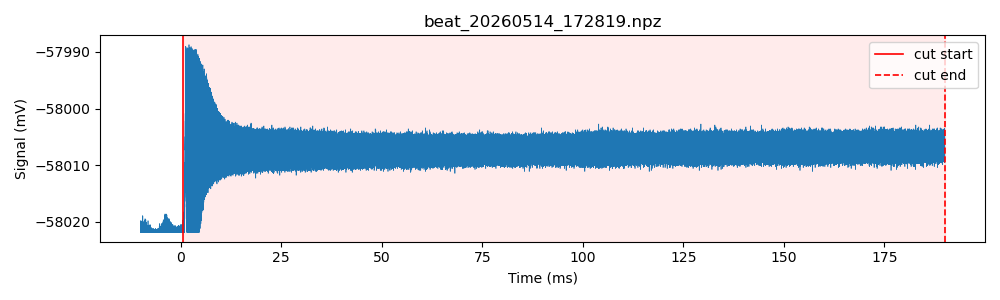

In [44]:
t_start = 0.5e-3      # seconds  <-- edit
t_end   = 190e-3    # seconds  <-- edit

# Clip to available range
t_start = max(t_start, t[0])
t_end   = min(t_end, t[-1])

i_start = np.searchsorted(t, t_start)
i_end   = np.searchsorted(t, t_end)
t_cut = t[i_start:i_end]
v_cut = v[i_start:i_end]
print(f"Cut: {t_start*1e3:.3f} to {t_end*1e3:.3f} ms ({len(v_cut)} pts, {len(v_cut)*xinc*1e3:.2f} ms)")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t * 1e3, v * 1e3, lw=0.5)
ax.axvline(t_start * 1e3, color="r", lw=1.2, label="cut start")
ax.axvline(t_end   * 1e3, color="r", lw=1.2, ls="--", label="cut end")
ax.axvspan(t_start * 1e3, t_end * 1e3, color="r", alpha=0.08)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Signal (mV)")
ax.set_title(fname.name)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

Waterfall: 1894 segments x 2501 freq bins
Segment duration: 0.100 ms,  freq resolution: 10000.0 Hz


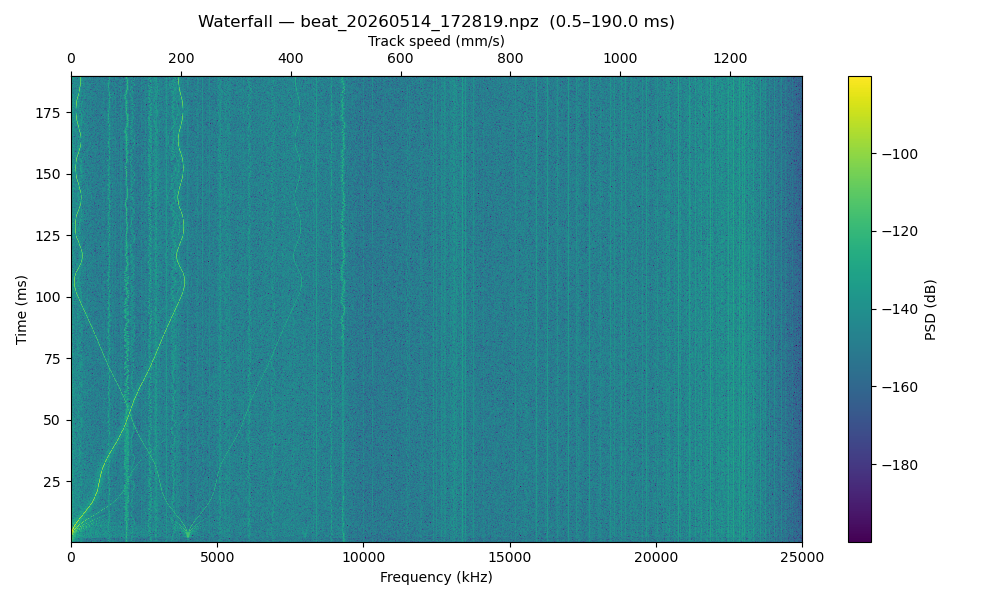

In [45]:
# %% Cell 3 — Waterfall on the cut data
seg_dur = .1e-3
overlap = 0
window_name = "hann"

nperseg = int(round(seg_dur / xinc))
nstep = int(round(nperseg * (1 - overlap)))
nseg = 1 + (len(v_cut) - nperseg) // nstep

if nseg < 1:
    raise ValueError(f"Cut region ({len(v_cut)*xinc*1e3:.2f} ms) shorter than segment ({seg_dur*1e3:.2f} ms)")

win = windows.get_window(window_name, nperseg)
win_norm = np.sum(win**2)

freqs = np.fft.rfftfreq(nperseg, d=xinc)
seg_times = t_cut[0] + (np.arange(nseg) * nstep + nperseg / 2) * xinc

spec = np.empty((nseg, len(freqs)), dtype=np.float32)
for i in range(nseg):
    chunk = v_cut[i*nstep : i*nstep + nperseg]
    chunk = (chunk - chunk.mean()) * win
    X = np.fft.rfft(chunk)
    psd = (np.abs(X)**2) / (fs * win_norm)
    psd[1:-1] *= 2
    spec[i] = psd

spec_db = 10 * np.log10(spec + 1e-20)
print(f"Waterfall: {nseg} segments x {len(freqs)} freq bins")
print(f"Segment duration: {seg_dur*1e3:.3f} ms,  freq resolution: {1/seg_dur:.1f} Hz")

WAVELENGTH = 852e-9   # m
N_BOUNCES  = 16       # factor (8 bounces, double-pass = 16)

def f_to_v(f_hz):
    return WAVELENGTH * f_hz / N_BOUNCES   # m/s

def v_to_f(v_ms):
    return N_BOUNCES * v_ms / WAVELENGTH   # Hz

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(
    freqs / 1e3,
    seg_times * 1e3,
    spec_db,
    shading="auto",
    cmap="viridis",
)
ax.set_xlabel("Frequency (kHz)")
ax.set_ylabel("Time (ms)")
ax.set_title(f"Waterfall — {fname.name}  ({t_start*1e3:.1f}–{t_end*1e3:.1f} ms)")
fig.colorbar(im, ax=ax, label="PSD (dB)")

# Secondary x-axis: velocity in mm/s
# kHz -> mm/s:  v_mm = (852e-9 / 16) * (f_khz * 1e3) * 1e3 = 53.25e-3 * f_khz
secax = ax.secondary_xaxis(
    "top",
    functions=(
        lambda f_khz: f_to_v(f_khz * 1e3) * 1e3,   # kHz -> mm/s
        lambda v_mm:  v_to_f(v_mm * 1e-3) / 1e3,   # mm/s -> kHz
    ),
)
secax.set_xlabel("Track speed (mm/s)")

# Optional zoom / clim
# ax.set_xlim(0, 100)
# im.set_clim(vmax=spec_db.max(), vmin=spec_db.max() - 60)

plt.tight_layout()
plt.show()

Section: 0.500–190.000 ms (9474999 pts)
Freq resolution: 5.28 Hz
Peak: 0.005 kHz, amplitude 0.217 mV, PSD -85.3 dB


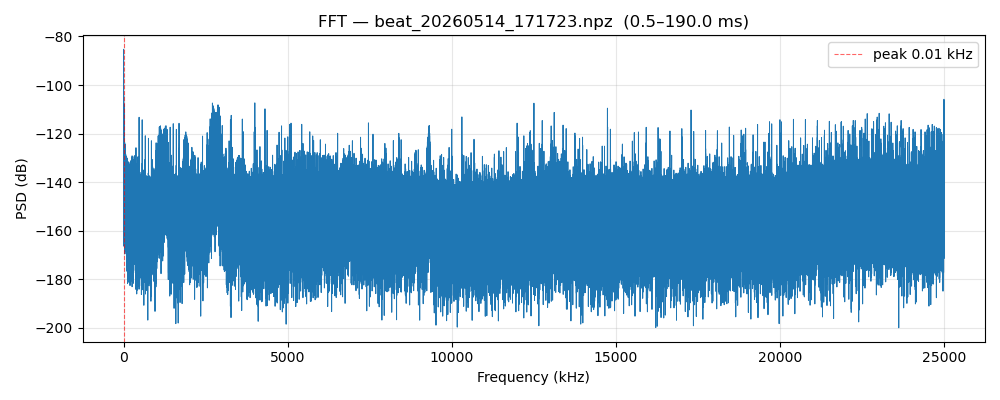

In [28]:
# %% Cell — FFT of the cut section
detrend = True
window_name = "hann"

x = v_cut.astype(np.float64)
if detrend:
    x = x - x.mean()

N = len(x)
win = windows.get_window(window_name, N)
win_norm = np.sum(win**2)

X = np.fft.rfft(x * win)
freqs_full = np.fft.rfftfreq(N, d=xinc)

psd = (np.abs(X)**2) / (fs * win_norm)
psd[1:-1] *= 2
psd_db = 10 * np.log10(psd + 1e-20)

# Amplitude spectrum (V) for peak reading
amp = (2 / np.sum(win)) * np.abs(X)
amp[0] /= 2
if N % 2 == 0:
    amp[-1] /= 2

# Peak
i_peak = np.argmax(psd[1:]) + 1   # skip DC
print(f"Section: {t_start*1e3:.3f}–{t_end*1e3:.3f} ms ({N} pts)")
print(f"Freq resolution: {fs/N:.2f} Hz")
print(f"Peak: {freqs_full[i_peak]/1e3:.3f} kHz, amplitude {amp[i_peak]*1e3:.3f} mV, PSD {psd_db[i_peak]:.1f} dB")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs_full / 1e3, psd_db, lw=0.7)
ax.axvline(freqs_full[i_peak] / 1e3, color="r", ls="--", lw=0.8, alpha=0.6,
           label=f"peak {freqs_full[i_peak]/1e3:.2f} kHz")
ax.set_xlabel("Frequency (kHz)")
ax.set_ylabel("PSD (dB)")
ax.set_title(f"FFT — {fname.name}  ({t_start*1e3:.1f}–{t_end*1e3:.1f} ms)")
ax.grid(True, alpha=0.3)
ax.legend()
# ax.set_xlim(0, 1000)   # kHz, optional zoom
plt.tight_layout()
plt.show()